### 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from IPython.display import display

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

In [8]:
ALGOS = ['mcsplit', 'rl', 'dal', 'll', 'dsb', 'rrsplit', 'symsplit']
DATA_DIR = Path('../../hpc/validation/results')

COLS = [
    'instance_a', 'instance_b', 'algo',
    'unified_size', 'unified_edges', 'unified_nodes', 'unified_time',
    'unified_aborted', 'unified_root_ub', 'unified_nodes_to_best',
    'unified_time_to_best', 'unified_cut_branches', 'unified_bound_pruned',
    'unified_sym_pruned', 'unified_conflicts',
    'ref_size', 'ref_nodes', 'ref_time', 'match'
]

In [9]:
dfs = []
for algo in ALGOS:
    path = DATA_DIR / f'{algo}_all.csv'
    if not path.exists():
        print(f'WARNING: {path} not found, skipping {algo}')
        continue
    df = pd.read_csv(path, header=None, names=COLS)
    dfs.append(df)
    print(f'Loaded {algo}: {len(df)} rows')

all_data = pd.concat(dfs, ignore_index=True)

# Type coercions
for col in ['unified_size', 'unified_aborted', 'unified_time', 'ref_size', 'ref_time', 'ref_nodes']:
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

all_data['size_diff'] = all_data['unified_size'] - all_data['ref_size']
print(f'\nTotal rows loaded: {len(all_data)}')

Loaded mcsplit: 8141 rows
Loaded rl: 8141 rows
Loaded dal: 8141 rows
Loaded ll: 8141 rows
Loaded dsb: 8140 rows
Loaded rrsplit: 8141 rows
Loaded symsplit: 8141 rows

Total rows loaded: 56986


### 2. Reclassify FAILs as MISSING_DATA

A FAIL where `unified_aborted=1` and `ref_time > TIME_THRESHOLD` (where `TIME_THRESHOLD=900`) is more accurately classified as MISSING_DATA - both solvers were struggling near the timeout boundary.

To find the threshold, first compute the mean speedup ratio per algorithm first.

In [10]:
passed_data = all_data[
    (all_data['match'] == 'PASS') &
    (all_data['unified_aborted'] == 0) &
    (all_data['ref_time'].notna()) &
    (all_data['ref_time'] > 0)
].copy()

passed_data['speedup'] = passed_data['unified_time'] / passed_data['ref_time']

speedup_summary = passed_data.groupby('algo')['speedup'].agg(['mean', 'median', 'std'])
speedup_summary.columns = ['mean_speedup', 'median_speedup', 'std_speedup']

In [11]:
print('>1.0 means our framework is slower')

print(speedup_summary.round(3))

>1.0 means our framework is slower
          mean_speedup  median_speedup  std_speedup
algo                                               
dal              1.145           1.089        0.334
dsb              1.038           1.018        0.123
ll               1.109           1.067        0.146
mcsplit          1.209           1.172        0.150
rl               1.188           1.145        0.148
rrsplit          1.093           1.042        0.162
symsplit         1.043           1.035        0.066


In [12]:
BORDERLINE_REF_TIME_THRESHOLD = 850.0
TIMEOUT = 1000.0

def reclassify_match(row):
    if row['match'] == 'FAIL' and row['unified_aborted'] == 1:
        if pd.notna(row['ref_time']) and row['ref_time'] > BORDERLINE_REF_TIME_THRESHOLD:
            return 'MISSING_DATA_BORDERLINE'
    return row['match']

all_data = all_data[all_data['algo'].isin(ALGOS)].copy()

for col in ['unified_aborted', 'ref_time']:
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

all_data['match_adj'] = all_data.apply(reclassify_match, axis=1)

summary = (all_data.groupby('algo')['match_adj']
           .value_counts()
           .unstack(fill_value=0)
           .rename_axis(index=None, columns=None))

In [13]:
print(summary)

          FAIL  MISSING_DATA  MISSING_DATA_BORDERLINE  PASS
dal         38          4228                        5  3869
dsb          0          4211                        0  3929
ll           0          4211                        1  3928
mcsplit      0          4182                        6  3952
rl           0          4245                        4  3891
rrsplit      0          4178                        4  3958
symsplit     0          4166                        1  3973


### 3. Per-Algorithm Completion Summary

In [14]:
summary_rows = []
for algo in ALGOS:
    sub = all_data[all_data['algo'] == algo]
    if sub.empty:
        continue
    total = len(sub)
    counts = sub['match_adj'].value_counts()
    row = {
        'algo': algo,
        'total': total,
        'PASS': counts.get('PASS', 0),
        'FAIL': counts.get('FAIL', 0),
        'MISSING_DATA': counts.get('MISSING_DATA', 0) + counts.get('MISSING_DATA_BORDERLINE', 0),
    }
    row['PASS_pct'] = 100 * row['PASS'] / total
    row['FAIL_pct'] = 100 * row['FAIL'] / total
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('algo')

In [15]:
print(summary_df.round(3))

          total  PASS  FAIL  MISSING_DATA  PASS_pct  FAIL_pct
algo                                                         
mcsplit    8140  3952     0          4188    48.550     0.000
rl         8140  3891     0          4249    47.801     0.000
dal        8140  3869    38          4233    47.531     0.467
ll         8140  3928     0          4212    48.256     0.000
dsb        8140  3929     0          4211    48.268     0.000
rrsplit    8140  3958     0          4182    48.624     0.000
symsplit   8140  3973     0          4167    48.808     0.000


### 4. Cross-Algorithm Correctness Check

`INSUFFICIENT_DATA` means there are fewer than two algorithms that have solved that instance.

In [16]:
completed = all_data[
    (all_data['unified_aborted'] == 0) &
    (all_data['unified_size'].notna())
][['instance_a', 'instance_b', 'algo', 'unified_size']]

pivot = completed.pivot_table(
    index=['instance_a', 'instance_b'],
    columns='algo',
    values='unified_size',
    aggfunc='first'
)

def classify(row):
    vals = row.dropna()
    if len(vals) < 2:
        return 'INSUFFICIENT_DATA'
    if vals.nunique() > 1:
        return 'REAL_MISMATCH'
    return 'OK'

pivot['status'] = pivot.apply(classify, axis=1)
status_counts = pivot['status'].value_counts()

In [17]:
print(len(pivot[pivot['status'] == "OK"]))

3966


In [18]:
print(len(pivot[pivot['status'] == "INSUFFICIENT_DATA"]))

14


In [19]:
print(len(pivot[pivot['status'] == "REAL_MISMATCH"]))

0


In [20]:
mismatches = pivot[pivot['status'] == 'REAL_MISMATCH']
if mismatches.empty:
    print('\nZero real mismatches - all completed algorithms agree on every instance.')
else:
    print(f'\nREAL MISMATCHES ({len(mismatches)}):')
    display(mismatches.drop(columns='status'))


Zero real mismatches - all completed algorithms agree on every instance.


### 5. Grouping Instances by Difficulty

"Easy" instances are instances where all 7 algorithms solved it within the `EASY_THRESHOLD` limit (which is 10).

"Hard" instances are instances where all 7 algorithms were unable to solve it within the `TIMEOUT` limit (which is 1000).

"Medium" instances are everything else.

In [21]:
ALGO_ORDER = ['mcsplit', 'rl', 'll', 'dal', 'dsb', 'rrsplit', 'symsplit']

In [22]:
num_cols = ['unified_size', 'unified_nodes', 'unified_time', 'unified_aborted',
            'ref_size', 'ref_nodes', 'ref_time']
for col in num_cols:
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

all_data = all_data[all_data['algo'].isin(ALGO_ORDER)].copy()

In [23]:
TIMEOUT = 1000.0
EASY_THRESHOLD = 10.0

inst_key = ['instance_a', 'instance_b']

solved = all_data.copy()

# Unified solve time (NaN if aborted)
solved['solve_time'] = solved.apply(
    lambda r: r['unified_time'] if r['unified_aborted'] == 0 else np.nan, axis=1
)

# Reference aborted flag
solved['ref_aborted'] = (solved['match'] == 'MISSING_DATA').astype(int)

time_pivot = solved.pivot_table(
    index=inst_key, columns='algo', values='solve_time', aggfunc='first'
)
abort_pivot = solved.pivot_table(
    index=inst_key, columns='algo', values='unified_aborted', aggfunc='first'
)
abort_pivot_ref = solved.pivot_table(
    index=inst_key, columns='algo', values='ref_aborted', aggfunc='first'
)

# Combined abort: 1 if EITHER unified OR reference timed out, NaN treated as aborted
abort_pivot_any = (
    (abort_pivot.fillna(1).astype(int) == 1) |
    (abort_pivot_ref.fillna(1).astype(int) == 1)
).astype(int)

# All unique instance pairs in the dataset
all_instances = all_data[inst_key].drop_duplicates().set_index(inst_key).index

def classify_instance(idx):
    # Check if instance exists in pivot (has at least some non-missing data)
    if idx not in abort_pivot_any.index:
        return 'hard'   # no data at all — all algos timed out, no ref data either

    row_abort = abort_pivot_any.loc[idx]
    row_time  = time_pivot.loc[idx] if idx in time_pivot.index else pd.Series(dtype=float)

    n_solved    = (row_abort == 0).sum()
    n_with_data = row_abort.notna().sum()
    n_fast      = (row_time <= EASY_THRESHOLD).sum()

    if n_solved == 0:
        return 'hard'
    if n_fast == n_with_data:
        return 'easy'
    return 'medium'

difficulty = pd.Series(
    [classify_instance(idx) for idx in all_instances],
    index=all_instances,
    name='difficulty'
)

In [24]:
print("Instance difficulty distribution (unified + reference, cross-algorithm):")
print(difficulty.value_counts())

Instance difficulty distribution (unified + reference, cross-algorithm):
difficulty
hard      4160
easy      2898
medium    1082
Name: count, dtype: int64


#### Unified

In [25]:
medium_instances = set(difficulty[difficulty == 'medium'].index)

# Filter all_data to just medium instances
med_mask = all_data.set_index(inst_key).index.isin(medium_instances)
medium_data = all_data[med_mask].copy()

medium_summary = medium_data.groupby('algo').apply(
    lambda x: pd.Series({
        'medium_total': len(x),
        'solved': (x['unified_aborted'] == 0).sum(),
        'solved_pct': 100 * (x['unified_aborted'] == 0).mean(),
        # 'mean_time': x.loc[x['unified_aborted'] == 0, 'unified_time'].mean(),
        # 'mean_nodes': x.loc[x['unified_aborted'] == 0, 'unified_nodes'].mean(),
    }),
    include_groups=False
).reindex(ALGO_ORDER)

#### Reference

In [26]:
# Reference difficulty classification + medium comparison
# Note: ref uses ref_time == 0 as the "aborted/timeout" proxy

solved_ref = all_data.copy()
solved_ref['ref_solved'] = (solved_ref['ref_time'] > 0) & (solved_ref['ref_time'] < TIMEOUT)
solved_ref['ref_solve_time'] = solved_ref.apply(
    lambda r: r['ref_time'] if (r['ref_time'] > 0 and r['ref_time'] < TIMEOUT) else np.nan, axis=1
)

# Reuse the SAME medium instance set defined by the unified classification,
# so both analyses compare on identical instances
med_mask_ref = all_data.set_index(inst_key).index.isin(medium_instances)
medium_data_ref = all_data[med_mask_ref].copy()

medium_summary_ref = medium_data_ref.groupby('algo').apply(
    lambda x: pd.Series({
        'medium_total': len(x),
        'solved': ((x['ref_time'] > 0) & (x['ref_time'] < TIMEOUT)).sum(),
        'solved_pct': 100 * ((x['ref_time'] > 0) & (x['ref_time'] < TIMEOUT)).mean(),
        # 'mean_time': x.loc[(x['ref_time'] > 0) & (x['ref_time'] < TIMEOUT), 'ref_time'].mean(),
        # 'mean_nodes': x.loc[(x['ref_time'] > 0) & (x['ref_time'] < TIMEOUT), 'ref_nodes'].mean(),
    }),
    include_groups=False
).reindex(ALGO_ORDER)

In [27]:
# Combine unified and reference medium-instance results with ranks
comparison = pd.DataFrame({
    ('Unified', 'solved'):     medium_summary['solved'],
    # ('Unified', 'solved_%'):   medium_summary['solved_pct'],
    ('Unified', 'rank'):       medium_summary['solved'].rank(ascending=False, method='min').astype(int),
    ('Reference', 'solved'):   medium_summary_ref['solved'],
    # ('Reference', 'solved_%'): medium_summary_ref['solved_pct'],
    ('Reference', 'rank'):     medium_summary_ref['solved'].rank(ascending=False, method='min').astype(int),
}).reindex(ALGO_ORDER)

comparison.columns = pd.MultiIndex.from_tuples(comparison.columns)

In [28]:
print(f"Shared medium instance set: {int(medium_summary['medium_total'].iloc[0])} instances\n")
print(comparison)

Shared medium instance set: 1082 instances

          Unified      Reference     
           solved rank    solved rank
algo                                 
mcsplit  1037.000    3  1052.000    3
rl        976.000    7   993.000    7
ll       1026.000    5  1031.000    4
dal       996.000    6  1013.000    6
dsb      1030.000    4  1031.000    4
rrsplit  1057.000    2  1064.000    2
symsplit 1071.000    1  1072.000    1


### 6. Overhead Analysis

Can use time per node as a proxy for per-node overhead.

Every time the search visits a node (makes a branching decision), it has to do some work. At minimum, every algorithm has to compute the bound, split the domains, and recurse. That's the baseline cost - what plain McSplit does. The RL-family algorithms do extra work on top of that: after every match, they update score tables (`lgrade`, `Q[v][w]`, DAL reward arrays), check thresholds, apply decay. RRSplit has to look up equivalence classes and check the `tried` set. SymSplit runs `break_h_sym` on candidates.

In [29]:
# Time per node (microseconds) — proxy for per-node overhead
medium_data['time_per_node_us'] = (
    medium_data['unified_time'] / medium_data['unified_nodes'] * 1e6
)

# Only on completed instances (aborted ones have truncated node counts)
completed = medium_data[medium_data['unified_aborted'] == 0]

time_per_node = completed.groupby('algo')['time_per_node_us'].agg(['mean', 'median'])

In [30]:
print("Unified time per node (microseconds):")
print(time_per_node.reindex(ALGO_ORDER).round(4))

Unified time per node (microseconds):
          mean  median
algo                  
mcsplit  0.148   0.131
rl       0.180   0.162
ll       0.189   0.167
dal      0.196   0.175
dsb      0.157   0.143
rrsplit  0.410   0.376
symsplit 0.135   0.121


In [31]:
# Reference time per node (microseconds)
for col in ['ref_time', 'ref_nodes']:
    medium_data[col] = pd.to_numeric(medium_data[col], errors='coerce')

medium_data['ref_time_per_node_us'] = (
    medium_data['ref_time'] / medium_data['ref_nodes'] * 1e6
)

# Only completed reference instances (ref_time > 0 and < TIMEOUT)
ref_completed = medium_data[
    (medium_data['ref_time'] > 0) & 
    (medium_data['ref_time'] < TIMEOUT) &
    (medium_data['ref_nodes'] > 0)
]

ref_time_per_node = ref_completed.groupby('algo')['ref_time_per_node_us'].agg(['mean', 'median'])

In [32]:
print("Reference time per node (microseconds):")
print(ref_time_per_node.reindex(ALGO_ORDER).round(4))

Reference time per node (microseconds):
          mean  median
algo                  
mcsplit  0.129   0.112
rl       0.158   0.143
ll       0.177   0.158
dal      0.182   0.163
dsb      0.156   0.143
rrsplit  0.403   0.368
symsplit 0.131   0.118


We can estimate what RL, LL, DAL's time would have been if it had the same search tree as McSplit.

i.e., `McSplit_time * ([algorithm]_per_node / McSplit_per_node)`

In [33]:
# Instances where McSplit completed but RL timed out on the medium set
mcsplit_med = medium_data[medium_data['algo'] == 'mcsplit'].set_index(inst_key)
rl_med = medium_data[medium_data['algo'] == 'rl'].set_index(inst_key)

common = mcsplit_med.index.intersection(rl_med.index)

mcsplit_solved = mcsplit_med.loc[common][mcsplit_med.loc[common]['unified_aborted'] == 0]

In [34]:
for algo in ['rl', 'll', 'dal']:
    algo_med = medium_data[medium_data['algo'] == algo].set_index(inst_key)
    algo_aborted = algo_med.loc[common][algo_med.loc[common]['unified_aborted'] == 1]
    contested_algo = mcsplit_solved.index.intersection(algo_aborted.index)
    
    overhead_ratio = {'rl': 0.162 / 0.131, 'll': 0.167/0.131, 'dal': 0.175/0.131}[algo]
    estimated_time = mcsplit_solved.loc[contested_algo, 'unified_time'] * overhead_ratio
    would_timeout = (estimated_time > TIMEOUT).sum()
    
    print(f"\n{algo}: McSplit solved but {algo} timed out: {len(contested_algo)}")
    print(f"Overhead ratio: {overhead_ratio:.3f}x")
    print(f"Would exceed timeout from overhead alone: {would_timeout} / {len(contested_algo)}")


rl: McSplit solved but rl timed out: 70
Overhead ratio: 1.237x
Would exceed timeout from overhead alone: 29 / 70

ll: McSplit solved but ll timed out: 30
Overhead ratio: 1.275x
Would exceed timeout from overhead alone: 23 / 30

dal: McSplit solved but dal timed out: 51
Overhead ratio: 1.336x
Would exceed timeout from overhead alone: 38 / 51


How many instances RRSplit / SymSplit solve that McSplit cannot, and how long they take on those instances.

The node reduction is large enough to overcome RRSplit's 3x per-node cost.

In [35]:
for algo in ['rrsplit', 'symsplit']:
    algo_med = medium_data[medium_data['algo'] == algo].set_index(inst_key)
    mcsplit_aborted = mcsplit_med.loc[common][mcsplit_med.loc[common]['unified_aborted'] == 1]
    algo_solved = algo_med.loc[common][algo_med.loc[common]['unified_aborted'] == 0]
    
    # Instances algo solved but McSplit timed out
    contested_algo = algo_solved.index.intersection(mcsplit_aborted.index)
    
    overhead_ratio = {'rrsplit': 0.376/0.131, 'symsplit': 0.121/0.131}[algo]
    
    # What would McSplit's time be on these, scaled by overhead ratio?
    algo_times = algo_solved.loc[contested_algo, 'unified_time']
    estimated_mcsplit_time = algo_times / overhead_ratio  # how fast McSplit would be per node
    
    print(f"\n{algo}: {algo} solved but McSplit timed out: {len(contested_algo)}")
    print(f"Per-node cost ratio vs McSplit: {overhead_ratio:.3f}x")
    print(f"{algo} solve times on these instances:")
    print(algo_times.describe().round(2))


rrsplit: rrsplit solved but McSplit timed out: 28


Per-node cost ratio vs McSplit: 2.870x
rrsplit solve times on these instances:
count    28.000
mean    805.100
std     146.770
min     443.510
25%     694.580
50%     842.510
75%     935.570
max     968.710
Name: unified_time, dtype: float64

symsplit: symsplit solved but McSplit timed out: 38
Per-node cost ratio vs McSplit: 0.924x
symsplit solve times on these instances:
count    38.000
mean    748.870
std     166.370
min     388.140
25%     625.210
50%     746.770
75%     874.560
max     996.940
Name: unified_time, dtype: float64


### 7. Reference DAL Bug

The reference DAL returns solutions inflated by exactly +1 vertex on a subset of instances. This is confirmed by cross-checking against 13 independent implementations.

In [36]:
dal_genuine = all_data[
    (all_data['algo'] == 'dal') &
    (all_data['unified_aborted'] == 0)
].copy()

dal_genuine['gap'] = dal_genuine['ref_size'] - dal_genuine['unified_size']
plus1 = dal_genuine[dal_genuine['gap'] == 1]

In [37]:
print('\nGap distribution (ref_size - our_dal_size):')
print(dal_genuine['gap'].value_counts().sort_index().to_string())

print(f'\nExactly +1 gap: {len(plus1)} / {len(dal_genuine)} cases ({100*len(plus1)/len(dal_genuine):.1f}%)')


Gap distribution (ref_size - our_dal_size):
gap
0.000    3859
1.000      29

Exactly +1 gap: 29 / 3894 cases (0.7%)


In [38]:
bug_instances = set(zip(plus1['instance_a'], plus1['instance_b']))
mask = all_data[['instance_a', 'instance_b']].apply(tuple, axis=1).isin(bug_instances)

cross = all_data[
    mask & (all_data['unified_aborted'] == 0)
].pivot_table(
    index=['instance_a', 'instance_b'],
    columns='algo',
    values='unified_size',
    aggfunc='first'
)

for algo in ALGOS:
    ref_col = all_data[
        (all_data['algo'] == algo) & mask
    ].set_index(['instance_a', 'instance_b'])['ref_size'].rename(f'ref_{algo}')
    cross = cross.join(ref_col)

In [39]:
print(cross)

                                           dal    dsb     ll  mcsplit     rl  rrsplit  symsplit  ref_mcsplit  ref_rl  ref_dal  ref_ll  ref_dsb  ref_rrsplit  ref_symsplit
instance_a          instance_b                                                                                                                                           
mcs10_b03_s40.A01   mcs10_b03_s40.B01   31.000 31.000 31.000   31.000 31.000   31.000    31.000       31.000  31.000   32.000  31.000   31.000       31.000        31.000
mcs10_b03_s40.A08   mcs10_b03_s40.B08   31.000 31.000 31.000   31.000 31.000   31.000    31.000       31.000  31.000   32.000  31.000   31.000       31.000        31.000
mcs10_b03_s50.A05   mcs10_b03_s50.B05   39.000 39.000 39.000   39.000    NaN   39.000    39.000       39.000     NaN   40.000  39.000   39.000       39.000        39.000
mcs10_b03_s50.A07   mcs10_b03_s50.B07   39.000 39.000 39.000   39.000 39.000   39.000    39.000       39.000  39.000   40.000  39.000   39.000       3

One example - mcs90_m4D_s90.A02

ref_dal finds 84, other algorithms find 83.

In [40]:
notable = all_data[
    all_data['instance_a'].str.contains('mcs90_m4D_s90.A02', na=False)
][['algo', 'unified_size', 'unified_nodes', 'unified_time', 'unified_aborted',
   'ref_size', 'ref_nodes', 'ref_time', 'match']]

In [41]:
print(notable)

           algo  unified_size  unified_nodes  unified_time  unified_aborted  ref_size     ref_nodes  ref_time match
7663    mcsplit        83.000      204628031        16.768            0.000    83.000 204628031.000    15.011  PASS
15804        rl        83.000      314336231        41.777            0.000    83.000 314336231.000    34.017  PASS
23945       dal        83.000      141559662        24.503            0.000    84.000  47698082.000     7.652  FAIL
32086        ll        83.000      214479975        31.963            0.000    83.000 214479975.000    28.603  PASS
40226       dsb        83.000      204618331        18.182            0.000    83.000 204618331.000    18.594  PASS
48367   rrsplit        83.000       64726820        13.911            0.000    83.000  28463273.000     5.909  PASS
56508  symsplit        83.000       70197035         5.509            0.000    83.000  70197035.000     5.172  PASS


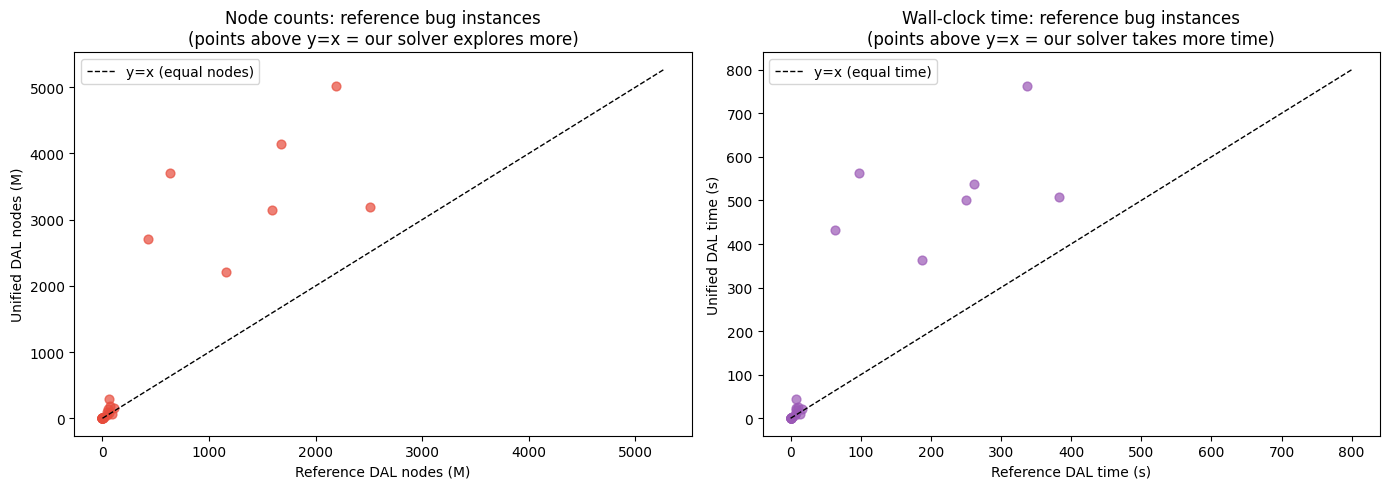

In [49]:
dal_data = all_data[all_data['algo'] == 'dal'].copy()
for col in ['unified_nodes', 'ref_nodes', 'unified_time', 'ref_time']:
    dal_data[col] = pd.to_numeric(dal_data[col], errors='coerce')

bug_mask = dal_data['instance_a'].isin([i for i, j in bug_instances]) & \
           dal_data['instance_b'].isin([j for i, j in bug_instances])

dal_bug = dal_data[bug_mask & (dal_data['unified_aborted'] == 0) &
                   dal_data['ref_nodes'].notna() & dal_data['unified_nodes'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(dal_bug['ref_nodes'] / 1e6, dal_bug['unified_nodes'] / 1e6,
                alpha=0.7, color='#e74c3c', s=40)
lim = max(dal_bug[['ref_nodes', 'unified_nodes']].max()) / 1e6 * 1.05
axes[0].plot([0, lim], [0, lim], 'k--', lw=1, label='y=x (equal nodes)')
axes[0].set_xlabel('Reference DAL nodes (M)')
axes[0].set_ylabel('Unified DAL nodes (M)')
axes[0].set_title('Node counts: reference bug instances\n(points above y=x = our solver explores more)')
axes[0].legend()

axes[1].scatter(dal_bug['ref_time'], dal_bug['unified_time'],
                alpha=0.7, color='#9b59b6', s=40)
lim2 = max(dal_bug[['ref_time', 'unified_time']].max()) * 1.05
axes[1].plot([0, lim2], [0, lim2], 'k--', lw=1, label='y=x (equal time)')
axes[1].set_xlabel('Reference DAL time (s)')
axes[1].set_ylabel('Unified DAL time (s)')
axes[1].set_title('Wall-clock time: reference bug instances\n(points above y=x = our solver takes more time)')
axes[1].legend()

plt.tight_layout()
plt.savefig('dal_bug_analysis.png', dpi=150)
plt.show()

### 8. Runtime Analysis

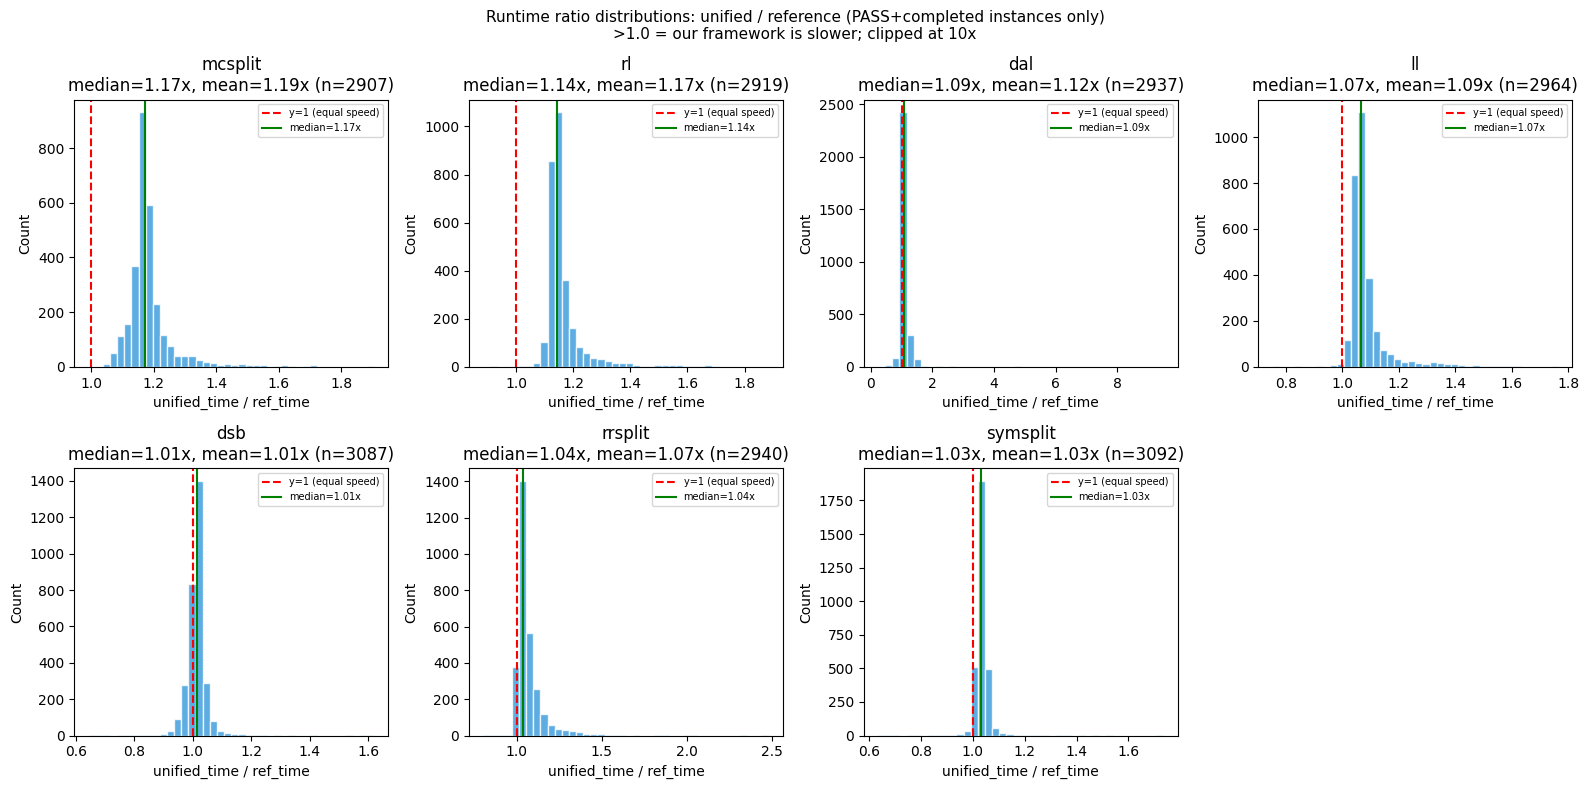

In [50]:
pass_comp = all_data[
    (all_data['match'] == 'PASS') &
    (all_data['unified_aborted'] == 0) &
    (all_data['ref_time'].notna()) &
    (all_data['ref_time'] > 0.001)  # skip near-zero ref times
].copy()
pass_comp['ratio'] = pass_comp['unified_time'] / pass_comp['ref_time']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, algo in enumerate(ALGOS):
    sub = pass_comp[pass_comp['algo'] == algo]['ratio'].dropna()
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].hist(sub.clip(upper=10), bins=40, color='#3498db', alpha=0.8, edgecolor='white')
    axes[i].axvline(1.0, color='red', linestyle='--', lw=1.5, label='y=1 (equal speed)')
    axes[i].axvline(sub.median(), color='green', linestyle='-', lw=1.5,
                    label=f'median={sub.median():.2f}x')
    axes[i].set_title(f'{algo}\nmedian={sub.median():.2f}x, mean={sub.mean():.2f}x (n={len(sub)})')
    axes[i].set_xlabel('unified_time / ref_time')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=7)

if len(ALGOS) < len(axes):
    for j in range(len(ALGOS), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Runtime ratio distributions: unified / reference (PASS+completed instances only)\n'
             '>1.0 = our framework is slower; clipped at 10x', fontsize=11)
plt.tight_layout()
plt.savefig('runtime_ratio_histograms.png', dpi=150)
plt.show()

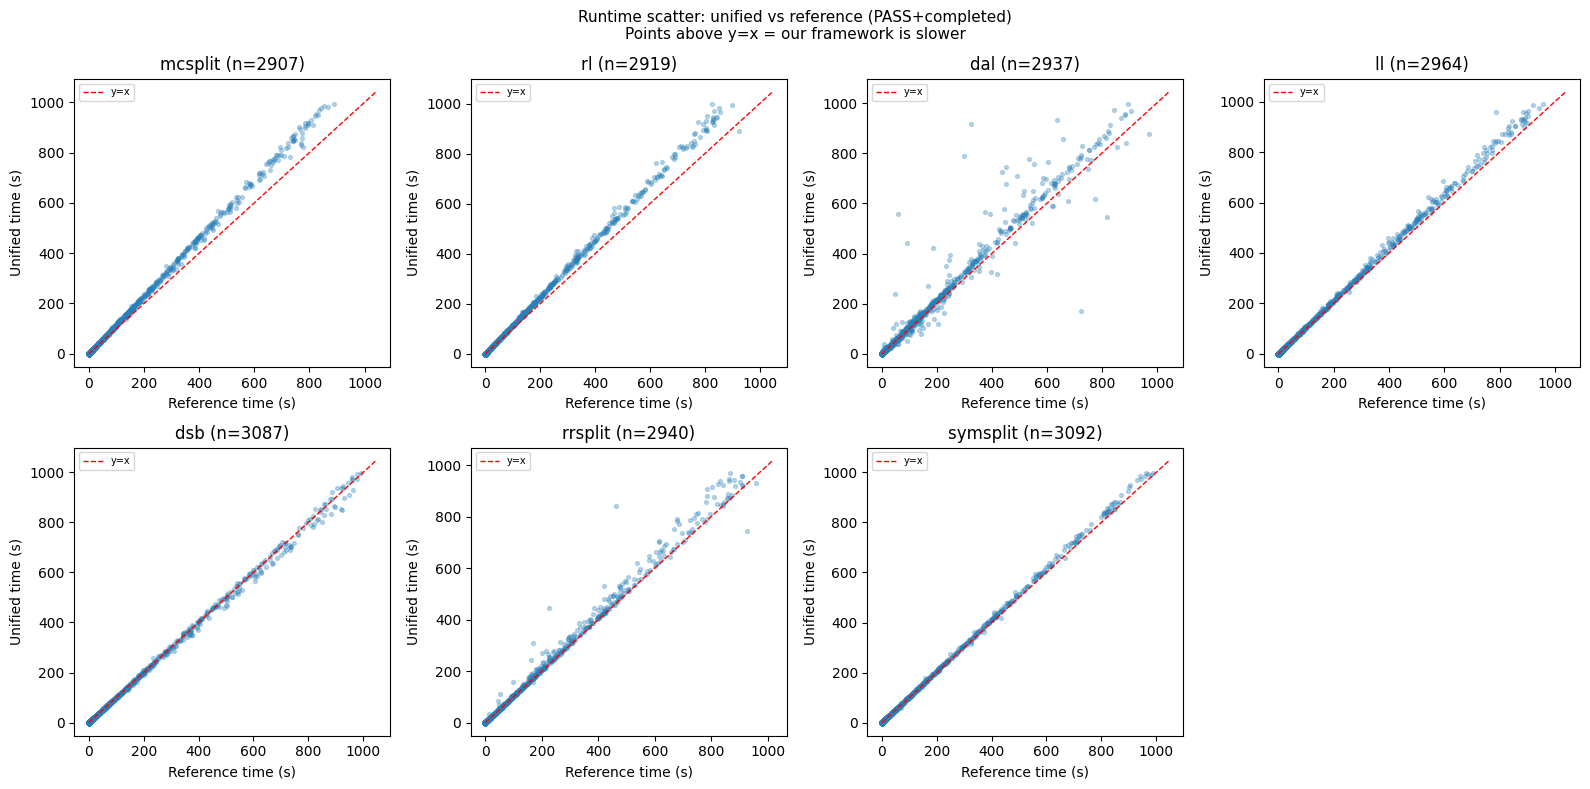

In [51]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, algo in enumerate(ALGOS):
    sub = pass_comp[pass_comp['algo'] == algo]
    if sub.empty:
        axes[i].set_visible(False)
        continue
    axes[i].scatter(sub['ref_time'], sub['unified_time'], alpha=0.3, s=8, color='#2980b9')
    lim = max(sub[['ref_time', 'unified_time']].max()) * 1.05
    axes[i].plot([0, lim], [0, lim], 'r--', lw=1, label='y=x')
    axes[i].set_xlabel('Reference time (s)')
    axes[i].set_ylabel('Unified time (s)')
    axes[i].set_title(f'{algo} (n={len(sub)})')
    axes[i].legend(fontsize=7)

if len(ALGOS) < len(axes):
    for j in range(len(ALGOS), len(axes)):
        axes[j].set_visible(False)

plt.suptitle('Runtime scatter: unified vs reference (PASS+completed)\n'
             'Points above y=x = our framework is slower', fontsize=11)
plt.tight_layout()
plt.savefig('runtime_scatter.png', dpi=150)
plt.show()

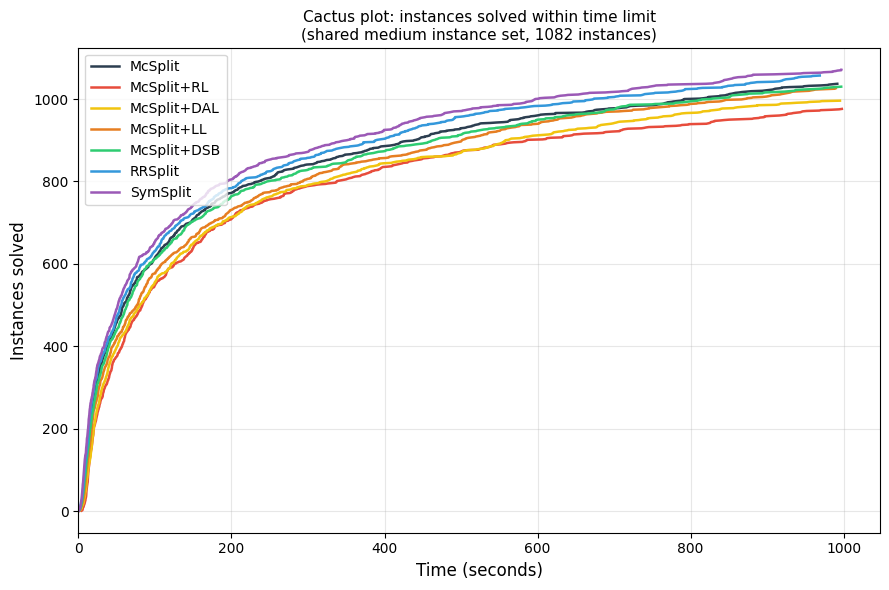

In [52]:
import matplotlib.pyplot as plt
import numpy as np

COLORS = {
    'mcsplit': '#2c3e50',
    'rl':      '#e74c3c',
    'll':      '#e67e22',
    'dal':     '#f1c40f',
    'dsb':     '#2ecc71',
    'rrsplit': '#3498db',
    'symsplit':'#9b59b6'
}
LABELS = {
    'mcsplit': 'McSplit',
    'rl':      'McSplit+RL',
    'll':      'McSplit+LL',
    'dal':     'McSplit+DAL',
    'dsb':     'McSplit+DSB',
    'rrsplit': 'RRSplit',
    'symsplit':'SymSplit'
}

# Use medium instances only for the fair comparison
medium_instances = set(difficulty[difficulty == 'medium'].index)
med_mask = all_data.set_index(inst_key).index.isin(medium_instances)
medium_data = all_data[med_mask].copy()

fig, ax = plt.subplots(figsize=(9, 6))

for algo in ALGOS:
    sub = medium_data[
        (medium_data['algo'] == algo) &
        (medium_data['unified_aborted'] == 0)
    ]['unified_time'].sort_values().values

    if len(sub) == 0:
        continue

    # x = cumulative instance count, y = time to solve that many
    x = np.arange(1, len(sub) + 1)
    ax.plot(sub, x, label=LABELS[algo], color=COLORS[algo], linewidth=1.8)

ax.set_ylabel('Instances solved', fontsize=12)
ax.set_xlabel('Time (seconds)', fontsize=12)
ax.set_title('Cactus plot: instances solved within time limit\n(shared medium instance set, 1082 instances)', fontsize=11)
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(left=0)
# ax.set_ylim(bottom=0, top=TIMEOUT)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cactus_time.png', dpi=150)
plt.show()
# print("Saved: cactus_time.png")

### 9. Node Analysis

In [46]:
for col in ['unified_nodes', 'ref_nodes']:
    all_data[col] = pd.to_numeric(all_data[col], errors='coerce')

node_comp = all_data[
    (all_data['match'] == 'PASS') &
    (all_data['unified_aborted'] == 0) &
    (all_data['ref_nodes'].notna()) &
    (all_data['ref_nodes'] > 0)
].copy()
node_comp['node_ratio'] = node_comp['unified_nodes'] / node_comp['ref_nodes']

node_summary = node_comp.groupby('algo')['node_ratio'].agg(['mean', 'median', 'std', 'count'])
node_summary.columns = ['mean_ratio', 'median_ratio', 'std_ratio', 'n']

In [47]:
print('Node count ratio (unified / reference) on PASS+completed instances:')
print('1.0 = identical search trees')
print(node_summary.round(4))

Node count ratio (unified / reference) on PASS+completed instances:
1.0 = identical search trees
          mean_ratio  median_ratio  std_ratio     n
algo                                               
dal            1.019         1.000      0.268  3859
dsb            1.000         1.000      0.000  3928
ll             1.000         1.000      0.000  3924
mcsplit        1.007         1.000      0.137  3935
rl             1.000         1.000      0.000  3874
rrsplit        1.016         1.003      0.052  3955
symsplit       1.000         1.000      0.000  3969


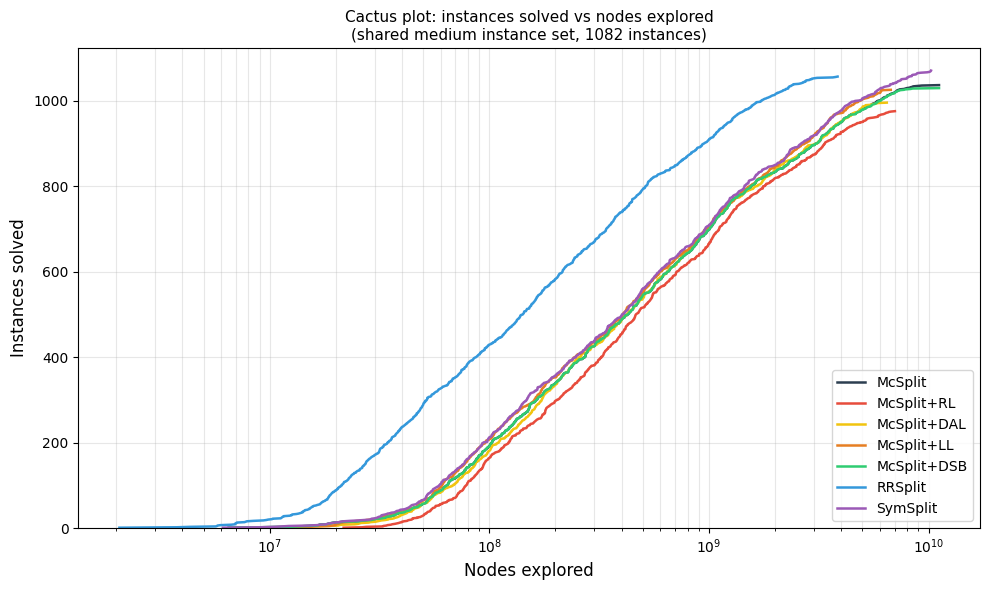

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

for algo in ALGOS:
    sub = medium_data[
        (medium_data['algo'] == algo) &
        (medium_data['unified_aborted'] == 0)
    ]['unified_nodes'].sort_values().values

    if len(sub) == 0:
        continue

    y = np.arange(1, len(sub) + 1)
    ax.plot(sub, y, label=LABELS[algo], color=COLORS[algo], linewidth=1.8)

ax.set_xlabel('Nodes explored', fontsize=12)
ax.set_ylabel('Instances solved', fontsize=12)
ax.set_xscale('log')  # ← log scale on X (nodes), not Y
ax.set_title('Cactus plot: instances solved vs nodes explored\n(shared medium instance set, 1082 instances)', fontsize=11)
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(bottom=0)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.savefig('cactus_nodes.png', dpi=150)
plt.show()